* The Task: Find a simple dataset with one continuous feature and one target (e.g., predicting a student's test score based on hours studied).
* Objectives: 
* Split the data into training and testing sets.
* Use sklearn.linear_model.LinearRegression to train the model.
* Create a scatter plot of the test data and overlay the predicted line of best fit.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


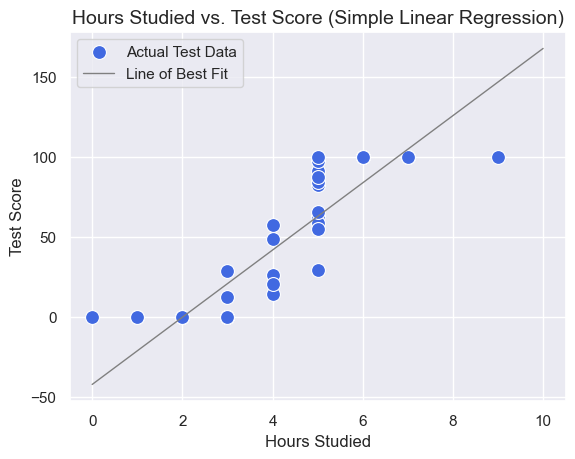

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
data = pd.read_csv('study_hour - study_hour.csv')
df = pd.DataFrame(data)

X = df[['Hours_Studied']]
y = df['Test_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

test_results = pd.DataFrame({
    'Hours_Studied': X_test['Hours_Studied'],
    'Actual_Score': y_test,
    'Predicted_Score': y_pred
})

x_range = np.linspace(df['Hours_Studied'].min(), df['Hours_Studied'].max(), 100).reshape(-1, 1)
y_range_pred = model.predict(x_range)

sns.set_theme(style="darkgrid")

sns.scatterplot(
    data=test_results, 
    x='Hours_Studied', 
    y='Actual_Score', 
    color='royalblue', 
    s=100, 
    label='Actual Test Data'
)

sns.lineplot(
    x=x_range.flatten(), 
    y=y_range_pred, 
    color='grey', 
    linewidth=1, 
    label='Line of Best Fit'
)

plt.title('Hours Studied vs. Test Score (Simple Linear Regression)', fontsize=14)
plt.xlabel('Hours Studied', fontsize=12)
plt.ylabel('Test Score', fontsize=12)
plt.legend()
plt.show()

Multiple Linear Regression & Feature Interpretation
* The Task: Use a multi-featured dataset like the California Housing Dataset.
* Objectives:
* Perform basic Exploratory Data Analysis (EDA) to check for correlations between features.
* Train a Multiple Linear Regression model.
* Extract and interpret the model's coefficients. Which features have the strongest positive or negative impact on the target variable?


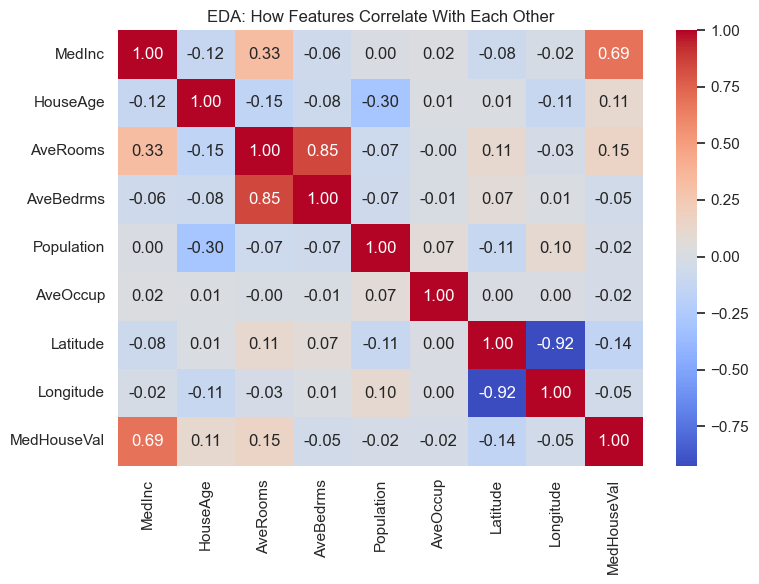

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

california = fetch_california_housing(as_frame=True)
df = california.frame

corr_matrix = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("EDA: How Features Correlate With Each Other")
plt.tight_layout()
plt.show()

X = california.data
y = california.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)